# Proyecto de K-Means - Sistema de Agrupacion de Casas

**Objetivo del proyecto:**

1. Comprender un dataset nuevo
2. Modelar los datos utilizando un K-Means
3. Predecir con el conjunto de test
4. Entrenar un modelo supervisado sobre las etiquetas generadas
5. Guardar ambos modelos

Queremos agrupar las casas segun **la region en la que se encuentran** y **el ingreso medio**,
asi que solo nos interesan tres columnas: `Latitude`, `Longitude` y `MedInc`.

In [117]:
# Your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [118]:
pd.set_option("display.max_columns", None)


In [119]:
#Carga del dataset desde la carpeta de datos en crudo
full_data = pd.read_csv("/workspaces/Machine-Learning-Kmeans/data/raw/housing.csv")

print("Filas:", full_data.shape[0])
print("Columnas:", full_data.shape[1])

full_data.head()

Filas: 20640
Columnas: 9


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [120]:
#Seleccion de las tres columnas que pide el enunciado
df = full_data[["Latitude", "Longitude", "MedInc"]]

df.head()

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


In [121]:
#Revision de nulos y duplicados
print("Nulos totales:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())
print("")
df.describe()

Nulos totales: 0
Filas duplicadas: 5



,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


### Distribucion de las variables

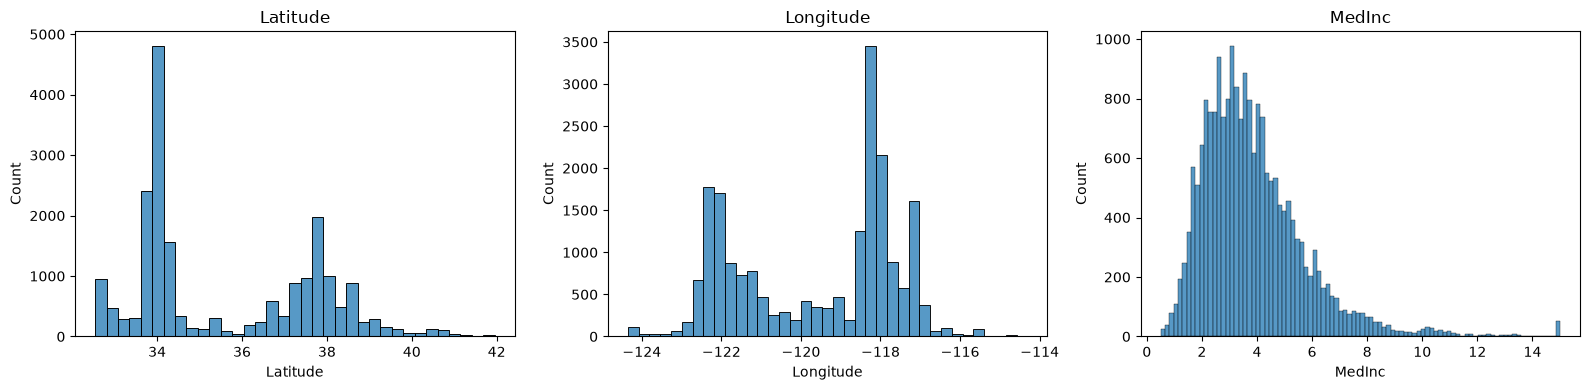

In [122]:
#Distribucion de las tres variables
fig, axis = plt.subplots(1, 3, figsize = (16, 4))

variables = ["Latitude", "Longitude", "MedInc"]

for i in range(3):
    sns.histplot(ax = axis[i], data = df, x = variables[i])
    axis[i].set_title(variables[i])

plt.tight_layout()
plt.show()

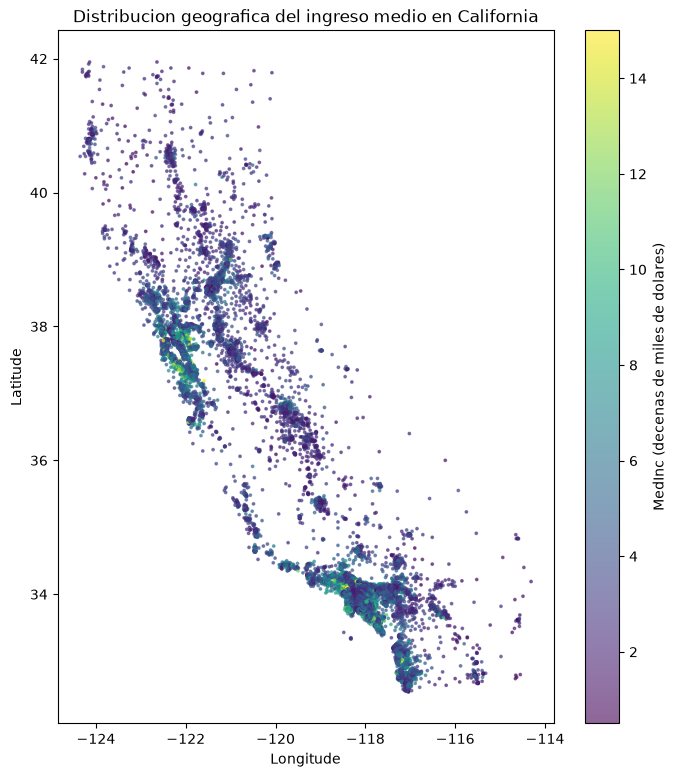

In [123]:
#Mapa de California coloreado por ingreso medio
plt.figure(figsize = (8, 9))
plt.scatter(df["Longitude"], df["Latitude"], c = df["MedInc"], cmap = "viridis", s = 3, alpha = 0.6)
plt.colorbar(label = "MedInc (decenas de miles de dolares)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribucion geografica del ingreso medio en California")
plt.show()

Los ingresos mas altos se concentran en la bahia de San Francisco y en zonas costeras del sur,
mientras que el valle central presenta ingresos claramente menores.

## Division en train y test


In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(df, test_size = 0.2, random_state = 42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16512, 3)
X_test: (4128, 3)


## Escalado

K-Means agrupa por distancia euclidea, asi que la variable con mayor recorrido numerico

In [125]:
#Comprobacion de que ocurre sin escalar
from sklearn.cluster import KMeans

unscaled_model = KMeans(n_clusters = 6, random_state = 42, n_init = 10)
unscaled_model.fit(X_train)

unscaled_result = X_train.copy()
unscaled_result["cluster"] = unscaled_model.labels_

print("Medias por cluster SIN escalar:")
unscaled_result.groupby("cluster")[["Latitude", "Longitude", "MedInc"]].mean().round(2)

Medias por cluster SIN escalar:


,Latitude,Longitude,MedInc
cluster,,,
0,36.06,-119.72,2.69
1,35.17,-119.52,11.12
2,33.82,-117.83,2.89
3,33.86,-118.02,5.59
4,38.35,-121.89,2.83
5,37.70,-121.96,5.51


Sin escalar, `MedInc` se impone: aparece un cluster con ingreso medio de 11,12 frente
a otros de 2,69 y 2,89. las latitudes: ese cluster de ingresos altos tiene una
media de 35,17 con desviacion muy amplia, es decir, agrupa casas repartidas por toda
California.

El modelo esta agrupando por dinero, ignorando la geografia. Y el enunciado pide clasificar
segun la region y el ingreso.

In [126]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), index = X_train.index, columns = X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index = X_test.index, columns = X_test.columns)

X_train_scaled.head()

,Latitude,Longitude,MedInc
14196,0.017021,0.729084,0.190322
8267,0.129787,0.616534,0.228452
17445,0.224468,0.385458,0.252162
14265,0.014894,0.721116,0.099488
2271,0.450000,0.453187,0.210638


## K-Means

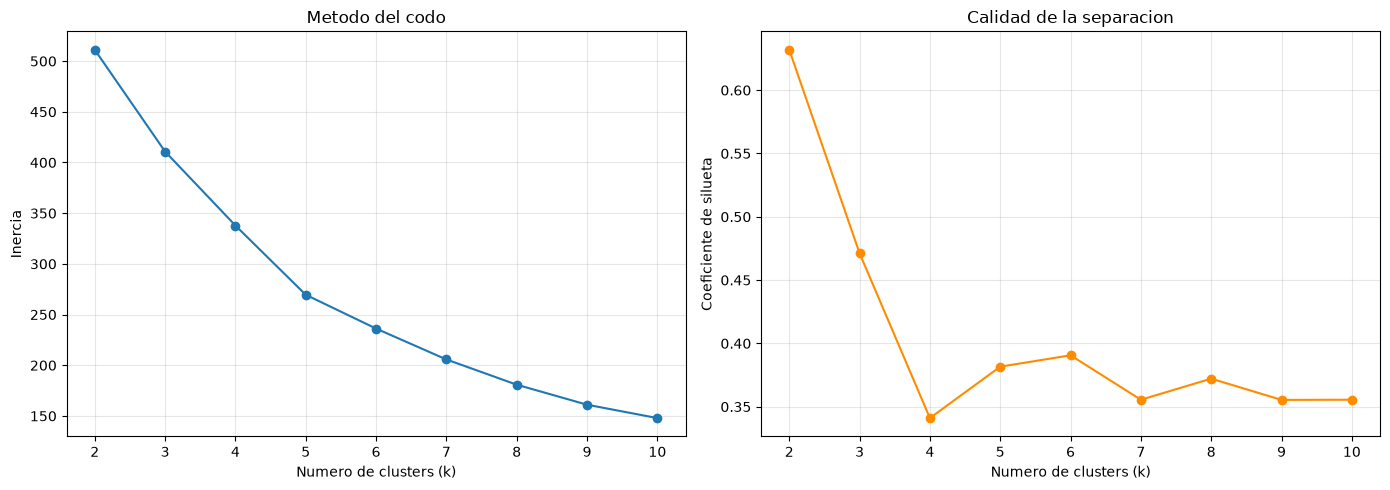

,k,inercia,silueta
0,2,511.2,0.6319
1,3,410.8,0.4712
2,4,337.8,0.3410
3,5,269.5,0.3816
4,6,236.2,0.3906
5,7,205.7,0.3555
6,8,180.8,0.3721
7,9,161.1,0.3554
8,10,147.9,0.3555


In [127]:
#Metodo del codo y coeficiente de silueta
from sklearn.metrics import silhouette_score

k_values = list(range(2, 11))
inertias = []
silhouettes = []

#Se usa una muestra para la silueta porque calcularla sobre 16.512 filas es muy lento
sample_data = X_train_scaled.sample(5000, random_state = 1)

for value in k_values:
    temporary_model = KMeans(n_clusters = value, random_state = 42, n_init = 10)
    temporary_model.fit(X_train_scaled)
    inertias.append(temporary_model.inertia_)
    silhouettes.append(silhouette_score(sample_data, temporary_model.predict(sample_data)))

fig, axis = plt.subplots(1, 2, figsize = (14, 5))

axis[0].plot(k_values, inertias, marker = "o")
axis[0].set_xlabel("Numero de clusters (k)")
axis[0].set_ylabel("Inercia")
axis[0].set_title("Metodo del codo")
axis[0].grid(alpha = 0.3)

axis[1].plot(k_values, silhouettes, marker = "o", color = "darkorange")
axis[1].set_xlabel("Numero de clusters (k)")
axis[1].set_ylabel("Coeficiente de silueta")
axis[1].set_title("Calidad de la separacion")
axis[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

elbow_table = pd.DataFrame()
elbow_table["k"] = k_values
elbow_table["inercia"] = np.round(inertias, 1)
elbow_table["silueta"] = np.round(silhouettes, 4)

elbow_table

In [128]:
#Modelo definitivo con los 6 clusters que pide el enunciado
kmeans_model = KMeans(n_clusters = 6, random_state = 42, n_init = 10)
kmeans_model.fit(X_train_scaled)

print("Inercia:", round(kmeans_model.inertia_, 2))
print("Coeficiente de silueta:", round(silhouette_score(sample_data, kmeans_model.predict(sample_data)), 4))
print("")
print("Formato de las etiquetas:", type(kmeans_model.labels_))
print("Valores que toma:", np.unique(kmeans_model.labels_))

Inercia: 236.21
Coeficiente de silueta: 0.3906

Formato de las etiquetas: <class 'numpy.ndarray'>
Valores que toma: [0 1 2 3 4 5]


In [129]:
#Asignacion del cluster como columna nueva, categorizada
train_result = X_train.copy()
train_result["cluster"] = kmeans_model.labels_
train_result["cluster"] = train_result["cluster"].astype("category")

print(train_result["cluster"].value_counts().sort_index())
print("")
train_result.head()

cluster
0    1588
1    2480
2    6355
3    4014
4    1373
5     702
Name: count, dtype: int64



,Latitude,Longitude,MedInc,cluster
14196,32.71,-117.03,3.2596,2
8267,33.77,-118.16,3.8125,2
17445,34.66,-120.48,4.1563,4
14265,32.69,-117.11,1.9425,2
2271,36.78,-119.80,3.5542,4


In [130]:
#Caracterizacion de cada cluster
cluster_profile = train_result.groupby("cluster", observed = True)[["Latitude", "Longitude", "MedInc"]].mean()
cluster_profile["casas"] = train_result["cluster"].value_counts().sort_index()

cluster_profile.round(3)

,Latitude,Longitude,MedInc,casas
cluster,,,,
0,37.660,-122.015,6.448,1588
1,33.875,-118.060,6.418,2480
2,33.814,-117.835,3.073,6355
3,37.942,-121.787,3.207,4014
4,35.999,-119.690,2.803,1373
5,40.044,-122.462,2.385,702


In [131]:
#Centroides devueltos a la escala original para poder interpretarlos
centroids = pd.DataFrame(scaler.inverse_transform(kmeans_model.cluster_centers_),
                         columns = X_train.columns)
centroids.index.name = "cluster"

centroids.round(3)

,Latitude,Longitude,MedInc
cluster,,,
0,37.661,-122.014,6.436
1,33.875,-118.059,6.415
2,33.814,-117.835,3.072
3,37.942,-121.785,3.201
4,35.997,-119.689,2.805
5,40.044,-122.462,2.385


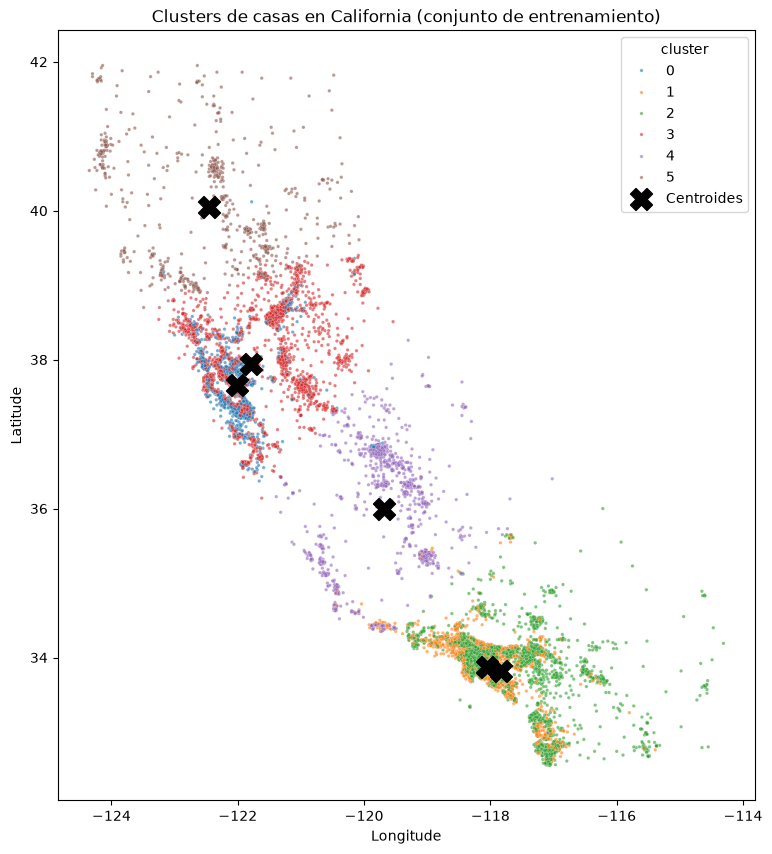

In [132]:
#Grafico de los clusters sobre el mapa de California
plt.figure(figsize = (9, 10))
sns.scatterplot(data = train_result, x = "Longitude", y = "Latitude", hue = "cluster",
                palette = "tab10", s = 6, alpha = 0.6)
plt.scatter(centroids["Longitude"], centroids["Latitude"], c = "black", marker = "X", s = 250,
            label = "Centroides")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Clusters de casas en California (conjunto de entrenamiento)")
plt.legend(title = "cluster")
plt.show()

## Predice con el conjunto de test

In [133]:
#Prediccion del cluster para las casas del conjunto de test
test_result = X_test.copy()
test_result["cluster"] = kmeans_model.predict(X_test_scaled)
test_result["cluster"] = test_result["cluster"].astype("category")

print(test_result["cluster"].value_counts().sort_index())
print("")
test_result.head()

cluster
0     366
1     592
2    1687
3     971
4     333
5     179
Name: count, dtype: int64



,Latitude,Longitude,MedInc,cluster
20046,36.06,-119.01,1.6812,4
3024,35.14,-119.46,2.5313,4
15663,37.80,-122.44,3.4801,3
20484,34.28,-118.72,5.7376,1
9814,36.62,-121.93,3.7250,3


In [134]:
#Comparacion de la proporcion de casas por cluster en train y test
proportion_table = pd.DataFrame()
proportion_table["train %"] = (train_result["cluster"].value_counts(normalize = True).sort_index() * 100).round(2)
proportion_table["test %"] = (test_result["cluster"].value_counts(normalize = True).sort_index() * 100).round(2)
proportion_table["diferencia"] = (proportion_table["train %"] - proportion_table["test %"]).round(2)

proportion_table

,train %,test %,diferencia
cluster,,,
0,9.62,8.87,0.75
1,15.02,14.34,0.68
2,38.49,40.87,-2.38
3,24.31,23.52,0.79
4,8.32,8.07,0.25
5,4.25,4.34,-0.09


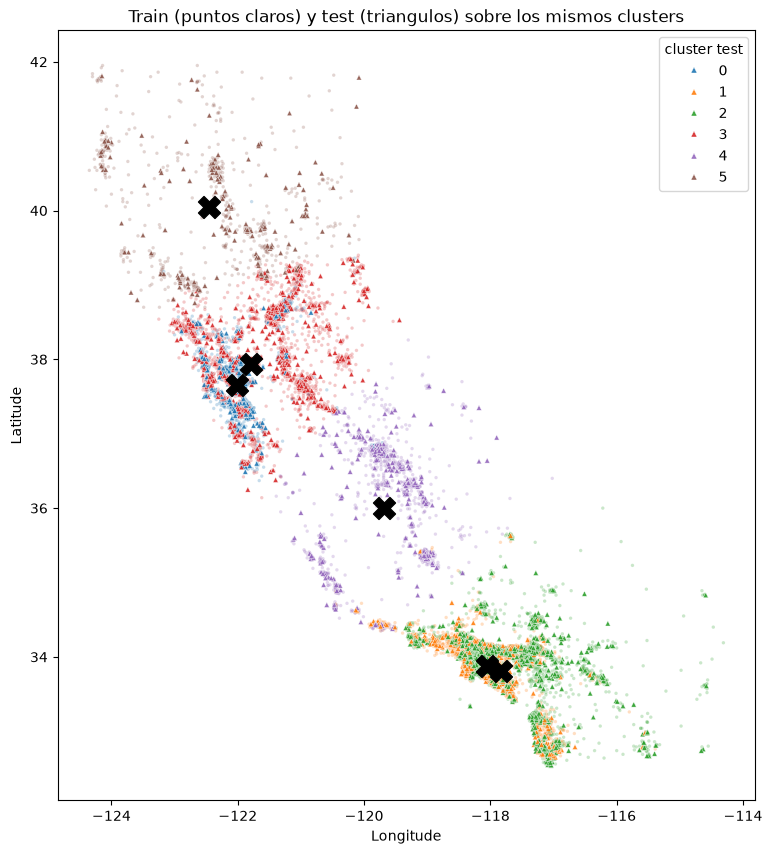

In [135]:
#Los puntos de test anadidos al grafico anterior
plt.figure(figsize = (9, 10))

sns.scatterplot(data = train_result, x = "Longitude", y = "Latitude", hue = "cluster",
                palette = "tab10", s = 6, alpha = 0.25, legend = False)
sns.scatterplot(data = test_result, x = "Longitude", y = "Latitude", hue = "cluster",
                palette = "tab10", s = 14, alpha = 0.9, marker = "^")
plt.scatter(centroids["Longitude"], centroids["Latitude"], c = "black", marker = "X", s = 250)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Train (puntos claros) y test (triangulos) sobre los mismos clusters")
plt.legend(title = "cluster test")
plt.show()

**¿Es satisfactoria la prediccion?** Si.

Los triangulos de test caen sobre las mismas regiones que los puntos de train de su color: no
hay puntos sueltos asignados a un cluster del otro extremo del estado. Ademas las proporciones
por cluster se mantienen casi identicas entre los dos conjuntos, con diferencias por debajo de
1 punto porcentual.

Esto confirma que los centroides aprendidos con train **generalizan** a casas nuevas. Tiene
sentido: con 16.512 casas de entrenamiento repartidas por todo el estado, los centroides estan
muy bien determinados.

## Modelo de clasificacion supervisada

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_train = kmeans_model.labels_
y_test = kmeans_model.predict(X_test_scaled)

candidates = [
    ["Regresion logistica", LogisticRegression(max_iter = 1000, random_state = 42)],
    ["Arbol de decision", DecisionTreeClassifier(random_state = 42)],
    ["Random forest", RandomForestClassifier(n_estimators = 100, random_state = 42, n_jobs = -1)]
]

candidate_rows = []

for row in candidates:
    model_name = row[0]
    model_object = row[1]
    model_object.fit(X_train_scaled, y_train)
    candidate_rows.append([
        model_name,
        accuracy_score(y_train, model_object.predict(X_train_scaled)),
        accuracy_score(y_test, model_object.predict(X_test_scaled))
    ])

candidate_table = pd.DataFrame(candidate_rows, columns = ["modelo", "acc train", "acc test"])
candidate_table = candidate_table.round(4)

candidate_table

,modelo,acc train,acc test
0,Regresion logistica,0.954,0.9525
1,Arbol de decision,1.000,0.9913
2,Random forest,1.000,0.9954


In [137]:
#Modelo supervisado definitivo
supervised_model = RandomForestClassifier(n_estimators = 100, random_state = 42, n_jobs = -1)
supervised_model.fit(X_train_scaled, y_train)

y_pred = supervised_model.predict(X_test_scaled)

print("Accuracy en train:", round(accuracy_score(y_train, supervised_model.predict(X_train_scaled)), 4))
print("Accuracy en test: ", round(accuracy_score(y_test, y_pred), 4))
print("")
print(classification_report(y_test, y_pred, digits = 3))

Accuracy en train: 1.0
Accuracy en test:  0.9954

              precision    recall  f1-score   support

           0      0.989     0.992     0.990       366
           1      0.995     0.995     0.995       592
           2      0.998     0.998     0.998      1687
           3      0.992     0.996     0.994       971
           4      0.997     0.997     0.997       333
           5      1.000     0.972     0.986       179

    accuracy                          0.995      4128
   macro avg      0.995     0.992     0.993      4128
weighted avg      0.995     0.995     0.995      4128



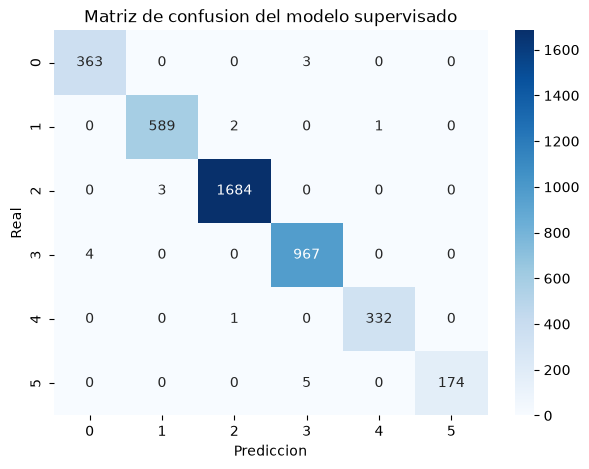

[[ 363    0    0    3    0    0]
 [   0  589    2    0    1    0]
 [   0    3 1684    0    0    0]
 [   4    0    0  967    0    0]
 [   0    0    1    0  332    0]
 [   0    0    0    5    0  174]]


In [138]:
#Matriz de confusion
plt.figure(figsize = (7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion del modelo supervisado")
plt.show()

print(confusion_matrix(y_test, y_pred))

/tmp/ipykernel_18095/449133005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = feature_importance.values, y = feature_importance.index, palette = "viridis")


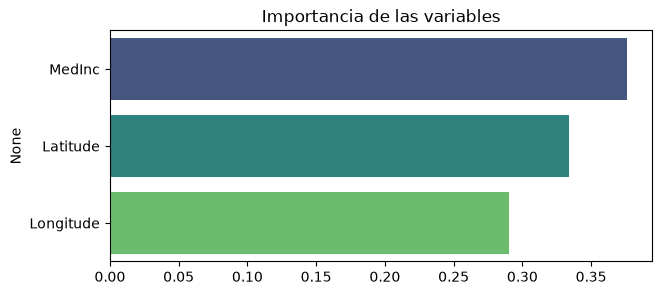

MedInc       0.3758
Latitude     0.3338
Longitude    0.2904
dtype: float64

In [139]:
#Importancia de las variables
feature_importance = pd.Series(supervised_model.feature_importances_, index = X_train.columns)
feature_importance = feature_importance.sort_values(ascending = False)

plt.figure(figsize = (7, 3))
sns.barplot(x = feature_importance.values, y = feature_importance.index, palette = "viridis")
plt.title("Importancia de las variables")
plt.show()

feature_importance.round(4)

## Guardar

In [140]:
import pickle

os.makedirs("./modelos_ml", exist_ok = True)

with open("./modelos_ml/kmeans_model.pkl", "wb") as file:
    pickle.dump(kmeans_model, file)

with open("./modelos_ml/supervised_model.pkl", "wb") as file:
    pickle.dump(supervised_model, file)

with open("./modelos_ml/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Modelos guardados en ./modelos_ml/")

Modelos guardados en ./modelos_ml/


In [141]:
#Guardado de los datos con la etiqueta de cluster asignada
train_result.to_csv("/workspaces/Machine-Learning-Kmeans/data/processed/train_with_clusters.csv", index = False)
test_result.to_csv("/workspaces/Machine-Learning-Kmeans/data/processed/test_with_clusters.csv", index = False)

print("Datos con clusters guardados en ./workspaces/Machine-Learning-Kmeans/data/processed")

Datos con clusters guardados en ./workspaces/Machine-Learning-Kmeans/data/processed
